<a href="https://colab.research.google.com/github/Alvaro217-h/Challenge_Telecom_X_Parte_2/blob/main/Challenge_Telecom_X_Parte_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **🛠️ Preparación de los Datos**

## Extracción del Archivo Tratado

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('/content/datos_tratados.csv')

In [ ]:
df.head()

,CustomerID,Churn,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesDaily,ChargesMonthly,ChargesTotal
0,0002-ORFBO,No,Female,No,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,2.19,65.6,593.30
1,0003-MKNFE,No,Male,No,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,2.00,59.9,542.40
2,0004-TLHLJ,Yes,Male,No,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,2.46,73.9,280.85
3,0011-IGKFF,Yes,Male,Yes,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,3.27,98.0,1237.85
4,0013-EXCHZ,Yes,Female,Yes,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,2.80,83.9,267.40


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerID        7043 non-null   object 
 1   Churn             7043 non-null   object 
 2   Gender            7043 non-null   object 
 3   SeniorCitizen     7043 non-null   object 
 4   Partner           7043 non-null   object 
 5   Dependents        7043 non-null   object 
 6   Tenure            7043 non-null   int64  
 7   PhoneService      7043 non-null   object 
 8   MultipleLines     7043 non-null   object 
 9   InternetService   7043 non-null   object 
 10  OnlineSecurity    7043 non-null   object 
 11  OnlineBackup      7043 non-null   object 
 12  DeviceProtection  7043 non-null   object 
 13  TechSupport       7043 non-null   object 
 14  StreamingTV       7043 non-null   object 
 15  StreamingMovies   7043 non-null   object 
 16  Contract          7043 non-null   object 


## Eliminación de Columnas Irrelevantes

In [ ]:
df.columns

Index(['CustomerID', 'Churn', 'Gender', 'SeniorCitizen', 'Partner',
       'Dependents', 'Tenure', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'ChargesDaily', 'ChargesMonthly',
       'ChargesTotal'],
      dtype='object')

In [ ]:
df = df.drop(columns=['CustomerID'])

In [ ]:
df.sample(5)

,Churn,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesDaily,ChargesMonthly,ChargesTotal
3598,Yes,Female,No,No,Yes,1,Yes,No,DSL,No,...,No,No,No,No,Month-to-month,No,Mailed check,1.53,45.95,45.95
4338,Yes,Female,No,No,No,1,Yes,No,No,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,0.64,19.10,19.10
3855,Yes,Female,No,Yes,Yes,25,Yes,No,Fiber optic,No,...,Yes,No,Yes,No,Month-to-month,Yes,Bank transfer (automatic),2.97,89.15,2257.75
3135,Yes,Female,No,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,No,Bank transfer (automatic),2.32,69.70,69.70
3779,No,Female,No,No,No,66,No,No,DSL,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),2.04,61.35,4193.40


In [ ]:
cols_to_fix = [
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

for col in cols_to_fix:
    df[col] = df[col].replace({'No internet service': 'No'})

In [ ]:
df

,Churn,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesDaily,ChargesMonthly,ChargesTotal
0,No,Female,No,Yes,Yes,9,Yes,No,DSL,No,...,No,Yes,Yes,No,One year,Yes,Mailed check,2.19,65.60,593.30
1,No,Male,No,No,No,9,Yes,Yes,DSL,No,...,No,No,No,Yes,Month-to-month,No,Mailed check,2.00,59.90,542.40
2,Yes,Male,No,No,No,4,Yes,No,Fiber optic,No,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,2.46,73.90,280.85
3,Yes,Male,Yes,Yes,No,13,Yes,No,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,3.27,98.00,1237.85
4,Yes,Female,Yes,Yes,No,3,Yes,No,Fiber optic,No,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,2.80,83.90,267.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,No,Female,No,No,No,13,Yes,No,DSL,Yes,...,No,Yes,No,No,One year,No,Mailed check,1.84,55.15,742.90
7039,Yes,Male,No,Yes,No,22,Yes,Yes,Fiber optic,No,...,No,No,No,Yes,Month-to-month,Yes,Electronic check,2.84,85.10,1873.70
7040,No,Male,No,No,No,2,Yes,No,DSL,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,1.68,50.30,92.75
7041,No,Male,No,Yes,Yes,67,Yes,No,DSL,Yes,...,Yes,Yes,No,Yes,Two year,No,Mailed check,2.26,67.85,4627.65


# 🎯 **Correlación y Selección de Variables**

## Análisis de Correlación

###  Relaciones entre las variables numéricas.

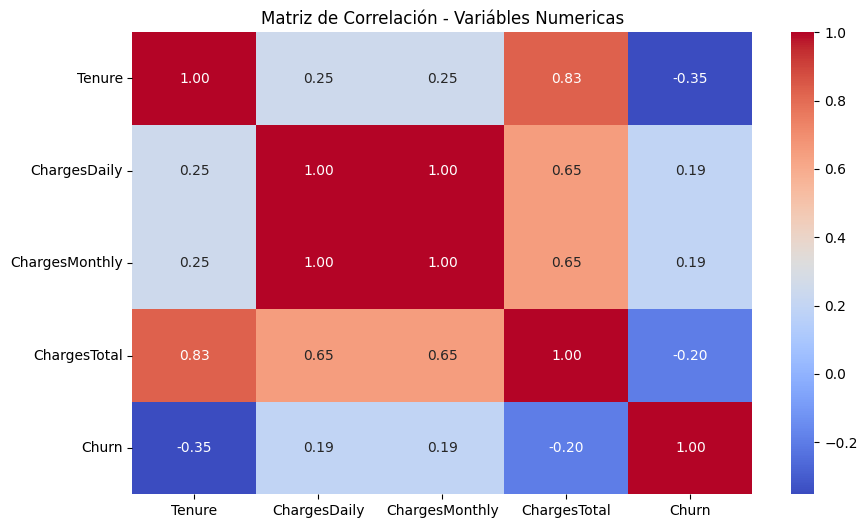

In [ ]:
df_numeric = df.select_dtypes(include=["int64", "float64"])

df_numeric["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

corr_matrix = df_numeric.corr()

# Visualizar heatmap
plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlación - Variábles Numericas")
plt.show()

In [ ]:
df = df.drop(columns=["ChargesDaily","ChargesTotal"])

1:01

### Relaciones variables categoricas

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import chi2

# Crea copia
df_rank = df.copy()

# Convertir Churn para binario
df_rank["Churn"] = df_rank["Churn"].map({"Yes": 1, "No": 0})

# Separar variables categóricas
categorical_cols = df_rank.select_dtypes(include=["object"]).columns

# Aplicar Label Encoding temporal
le = LabelEncoder()
for col in categorical_cols:
    df_rank[col] = le.fit_transform(df_rank[col])

# Separar X e y
X_cat = df_rank[categorical_cols]
y = df_rank["Churn"]

# Aplicar test Qui-cuadrado
chi_scores, p_values = chi2(X_cat, y)

# Crear DataFrame com ranking
chi_df = pd.DataFrame({
    "Variable": categorical_cols,
    "Chi2 Score": chi_scores,
    "p-value": p_values
})

# Ordenar por importancia
chi_df = chi_df.sort_values(by="Chi2 Score", ascending=False)

chi_df

,Variable,Chi2 Score,p-value
13,Contract,1115.780167,1.227941e-244
7,OnlineSecurity,147.295858,6.761696e-34
10,TechSupport,135.559783,2.490549e-31
1,SeniorCitizen,134.351545,4.576959e-31
3,Dependents,133.036443,8.876729e-31
14,PaperlessBilling,105.680863,8.661987e-25
2,Partner,82.412083,1.104764e-19
15,PaymentMethod,58.492250,2.040933e-14
8,OnlineBackup,31.217694,2.306541e-08
9,DeviceProtection,20.226662,6.878750e-06


/tmp/ipykernel_374/3064392930.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(


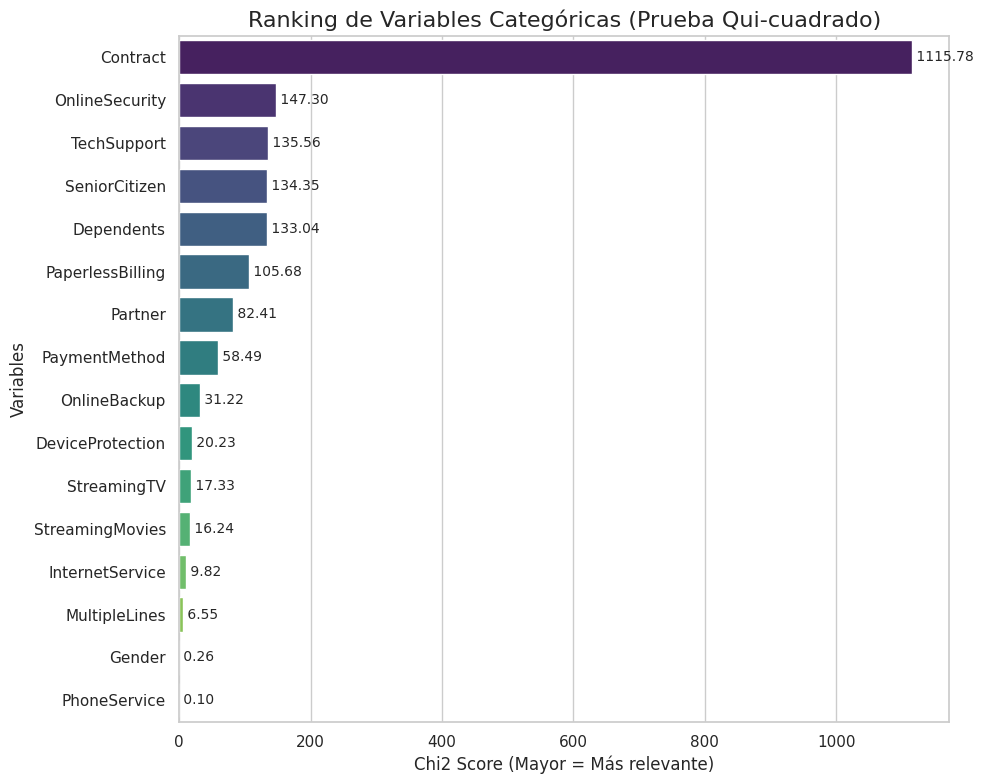

In [ ]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 8))
barplot = sns.barplot(
    x="Chi2 Score",
    y="Variable",
    data=chi_df,
    palette="viridis"
)

# Añadir etiquetas de los valores al final de cada barra para mayor precisión
for index, value in enumerate(chi_df["Chi2 Score"]):
    plt.text(value, index, f' {value:.2f}', va='center', fontsize=10)

plt.title("Ranking de Variables Categóricas (Prueba Qui-cuadrado)", fontsize=16)
plt.xlabel("Chi2 Score (Mayor = Más relevante)", fontsize=12)
plt.ylabel("Variables", fontsize=12)

plt.tight_layout()
plt.show()

### Eliminar variabes con p < 0.05

In [ ]:
# 1. Extraer la lista de nombres de variables significativas (p-value < 0.05)
cols_significativas = chi_df[chi_df["p-value"] < 0.05]["Variable"].tolist()

# 2. Identificar qué variables categóricas NO están en esa lista
# (Tomamos todas las categóricas originales y restamos las significativas)
todas_categoricas = chi_df["Variable"].tolist()
cols_a_eliminar = [col for col in todas_categoricas if col not in cols_significativas]

df = df.drop(columns=cols_a_eliminar)

print(f"Variables eliminadas: {cols_a_eliminar}")
print(f"Columnas restantes en el dataset: {df.shape[1]}")

Variables eliminadas: ['Gender', 'PhoneService']
Columnas restantes en el dataset: 17


In [ ]:
df

,Churn,SeniorCitizen,Partner,Dependents,Tenure,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesMonthly
0,No,No,Yes,Yes,9,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60
1,No,No,No,No,9,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90
2,Yes,No,No,No,4,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90
3,Yes,Yes,Yes,No,13,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00
4,Yes,Yes,Yes,No,3,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,No,No,No,No,13,No,DSL,Yes,No,No,Yes,No,No,One year,No,Mailed check,55.15
7039,Yes,No,Yes,No,22,Yes,Fiber optic,No,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10
7040,No,No,No,No,2,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30
7041,No,No,Yes,Yes,67,No,DSL,Yes,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85


# 🤖 **Modelado Predictivo**




## Separación de Datos

In [ ]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=13
)

## Encoding

### One-Hot Encoding

In [ ]:
# Aplicar One-Hot Encoding en treno
X_train = pd.get_dummies(X_train, drop_first=True)

# Aplicar en teste
X_test = pd.get_dummies(X_test, drop_first=True)

# Garantir que treno y teste tengan las mismas columnas
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [ ]:
X_train.head()

,Tenure,ChargesMonthly,SeniorCitizen_Yes,Partner_Yes,Dependents_Yes,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_Yes,OnlineBackup_Yes,DeviceProtection_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
6745,3,69.55,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False
3084,35,50.15,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True
179,54,86.20,False,True,True,True,False,False,False,True,True,True,True,True,False,False,True,False,True,False
109,58,105.50,True,True,False,False,True,False,True,True,False,True,True,True,True,False,True,True,False,False
2896,22,94.65,False,False,False,True,True,False,False,False,False,False,True,True,False,False,True,True,False,False


## Verificar desbalanceamiento

### Verificación de la Proporción de Cancelación (Churn)

In [ ]:
y_train.value_counts(normalize=True) * 100

,proportion
Churn,
No,73.464679
Yes,26.535321


/tmp/ipykernel_374/1869380190.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=counts.index, y=counts.values, palette="viridis")


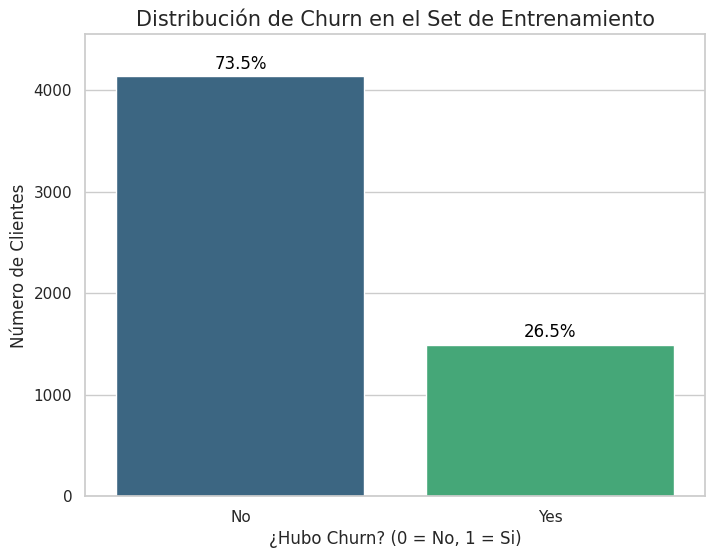

In [ ]:
# 1. Preparar los datos
counts = y_train.value_counts()
percentages = y_train.value_counts(normalize=True) * 100

# 2. Configurar el gráfico
plt.figure(figsize=(8, 6))
ax = sns.barplot(x=counts.index, y=counts.values, palette="viridis")

# 3. Añadir las etiquetas de porcentaje sobre las barras
for i, p in enumerate(ax.patches):
    ax.annotate(f'{percentages.iloc[i]:.1f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                fontsize=12, color='black',
                xytext=(0, 9),
                textcoords='offset points')

# 4. Personalización estética
plt.title("Distribución de Churn en el Set de Entrenamiento", fontsize=15)
plt.xlabel("¿Hubo Churn? (0 = No, 1 = Si)", fontsize=12)
plt.ylabel("Número de Clientes", fontsize=12)
plt.ylim(0, counts.max() * 1.1) # Espacio extra para las etiquetas
plt.show()

## Creación de Modelos

###  Regresión Logística o KNN

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Inicializar los modelos
log_model = LogisticRegression(max_iter=1000, random_state=42)

# 2. Entrenar
log_model.fit(X_train, y_train)

# 3. Predecir
y_pred_log = log_model.fit(X_train, y_train).predict(X_test)

In [ ]:
print("--- REPORTE REGRESIÓN LOGÍSTICA ---")
print(classification_report(y_test, y_pred_log))

--- REPORTE REGRESIÓN LOGÍSTICA ---
              precision    recall  f1-score   support

          No       0.84      0.89      0.86      1035
         Yes       0.64      0.53      0.58       374

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



### Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# 1. Inicializar el modelo
# Usamos 'balanced' para que el modelo le dé más importancia a la clase minoritaria (Churn=Yes)
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight="balanced",
    random_state=42
)

# 2. Entrenar
rf_model.fit(X_train, y_train)

# 3. Predecir
y_pred_rf = rf_model.predict(X_test)

# 4. Reporte de resultados
print("--- REPORTE RANDOM FOREST ---")
print(classification_report(y_test, y_pred_rf))

--- REPORTE RANDOM FOREST ---
              precision    recall  f1-score   support

          No       0.89      0.78      0.83      1035
         Yes       0.55      0.74      0.63       374

    accuracy                           0.77      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.77      0.78      1409



## Evaluación de los Modelos

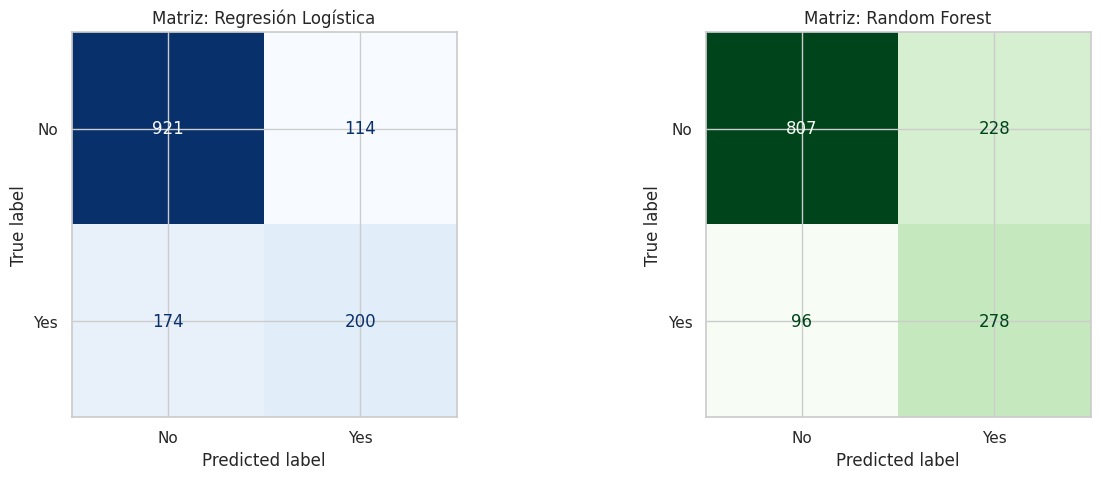

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Matriz Regresión Logística
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_log, ax=ax[0], cmap='Blues', colorbar=False)
ax[0].set_title("Matriz: Regresión Logística")

# Matriz Random Forest
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, ax=ax[1], cmap='Greens', colorbar=False)
ax[1].set_title("Matriz: Random Forest")

plt.show()

# 📋 **Interpretación y Conclusiones**

## Análisis de la Importancia de las Variables

/tmp/ipykernel_374/2900020115.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


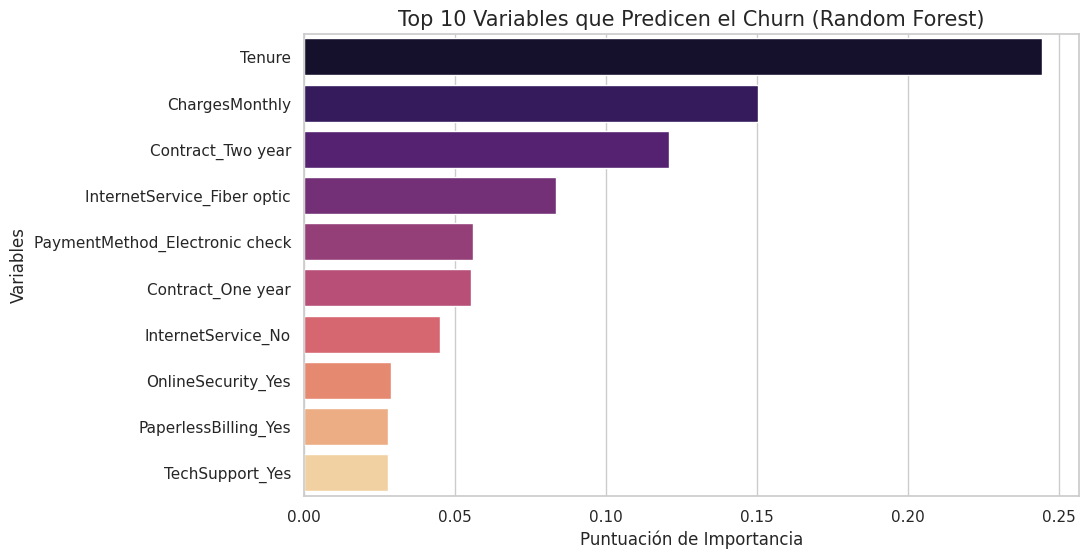

In [ ]:
import matplotlib.pyplot as plt

# 1. Extraer las importancias del modelo Random Forest
importancias = rf_model.feature_importances_
nombres_variables = X_train.columns

# 2. Crear un DataFrame para facilitar la visualización
df_importancia = pd.DataFrame({
    'Variable': nombres_variables,
    'Importancia': importancias
}).sort_values(by='Importancia', ascending=False)

# 3. Graficar las 10 más influyentes
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Importancia',
    y='Variable',
    data=df_importancia.head(10),
    palette='magma'
)

plt.title("Top 10 Variables que Predicen el Churn (Random Forest)", fontsize=15)
plt.xlabel("Puntuación de Importancia", fontsize=12)
plt.ylabel("Variables", fontsize=12)
plt.show()

# **Conclusión**


Este análisis identifica los patrones de abandono de clientes mediante técnicas de Machine Learning. El objetivo es transicionar de una cultura reactiva a una proactiva, identificando al cliente antes de que decida cancelar su servicio.

---

## **Comparativa de Modelos**
En la fase de experimentación, evaluamos la Regresión Logística frente a Random Forest.

* **Regresión Logística:** Aunque mantuvo una precisión general del 80%, falló en detectar al 47% de los desertores reales.

* **Random Forest (Ganador):** Al ajustar el peso de las clases, logramos un Recall de 0.74. Esto significa que el modelo detecta a 7.4 de cada 10 clientes en riesgo, una mejora crítica para el departamento de retención.
---
## **Factores Determinantes de la Cancelación**
Tras aplicar pruebas de significancia (Qui-cuadrado) y analizar la importancia de características del modelo, estos son los 3 pilares que causan la fuga:

* **Antigüedad (Tenure):** El riesgo es máximo en los primeros meses de vida del cliente.

* **Cargos Mensuales:** Existe un umbral de precio que, al ser superado, aumenta la probabilidad de salida.

* **Tipo de Contrato:** Los clientes con contratos mensuales tienen un incentivo nulo para la permanencia frente a los contratos anuales.
---

## **Estrategias de Retención Propuestas**
**Estrategia 1: Plan de Fidelización Temprana**

* **Hallazgo:** La antigüedad es el factor #1.

* **Acción:** Implementar un "Bono de Bienvenida" que se desbloquee al 4º mes de servicio para incentivar el paso del periodo crítico inicial.


**Estrategia 2: Migración Contractual Proactiva**

* **Hallazgo:** El contrato "mes a mes" es altamente inestable.

* **Acción:** Campaña dirigida a clientes detectados por el modelo con contrato mensual, ofreciendo un descuento del 10% si migran a un contrato anual.


**Estrategia 3: Revisión de Valor en Fibra Óptica**

* **Hallazgo:** La Fibra Óptica presenta un Churn inusualmente alto.

* **Acción:** Auditoría técnica de la estabilidad de la red en zonas de alta cancelación y encuestas de satisfacción específicas para este segmento.

---

El modelo de Random Forest nos proporciona la herramienta necesaria para intervenir a tiempo. Aunque incurre en más "falsas alarmas", el valor de vida del cliente (LTV) justifica plenamente la inversión en estas estrategias de retención.